# Task 1: Analysis of Symptom Co-Occurrence Patterns using Apriori Algorithm with non-merged data

## 1.1 Setup and Imports

In [3]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from apriori_miner import AprioriMiner

In [ ]:
def clean_disease_data(df):
    """
    Basic cleaning: whitespace, empty strings, basic formatting.
    """
    df = df.copy()
    # Remove whitespace
    string_cols = df.select_dtypes(include="object").columns
    for col in string_cols:
        df[col] = df[col].str.strip() if df[col].dtype == "object" else df[col]

    # Replace empty strings with NaN
    df = df.replace("", np.nan)

    # Lowercase and replace spaces with underscores
    symptom_cols = [col for col in df.columns if "Symptom" in col]
    for col in symptom_cols:
        df[col] = (
            df[col].str.lower().str.replace(" _", "_").str.replace("_ ", "_")
        )

    return df


def normalize_symptoms(df, normalization_dict):
    """
    Normalize symptoms using a mapping dictionary.
    """
    df = df.copy()

    symptom_cols = [col for col in df.columns if "Symptom" in col]

    for col in symptom_cols:
        df[col] = df[col].map(
            lambda x: normalization_dict.get(x, x) if pd.notna(x) else x
        )

    return df


def preprocess_disease_data(df, norm_dict):
    """Clean -> normalize (NO merging)"""
    df = clean_disease_data(df)
    df = normalize_symptoms(df, norm_dict)
    return df


def convert_to_transactions(df, keep_disease_label=False):
    """
    Convert disease-symptom dataframe to transaction format for Apriori.

    Each ROW becomes a transaction containing its symptoms.

    Parameters:
    - df: DataFrame with Disease and Symptom columns
    - keep_disease_label: If True, return (disease, symptoms) tuples

    Returns:
    - If keep_disease_label=False: list of frozensets
    - If keep_disease_label=True: list of (disease, frozenset) tuples
    """
    transactions = []
    symptom_cols = [col for col in df.columns if "Symptom" in col]

    for _, row in df.iterrows():
        disease = row["Disease"]
        # Collect non-null symptoms for this row
        symptoms = [row[col] for col in symptom_cols if pd.notna(row[col])]

        # Only add if there are symptoms
        if symptoms:
            if keep_disease_label:
                transactions.append((disease, frozenset(symptoms)))
            else:
                transactions.append(frozenset(symptoms))

    return transactions


# ============================================================================
# MAIN ANALYSIS
# ============================================================================

# Load raw data
df_raw = pd.read_csv("../data/itachi9604_disease_symptom_description_dataset.csv")
print(f"Raw data shape: {df_raw.shape}")
print(f"Unique diseases: {df_raw['Disease'].nunique()}")
print(f"Total patient instances: {len(df_raw)}")
display(df_raw.head())

# Preprocess (clean + normalize) - NO MERGING
normalization_dict = {
    # Add your normalization mappings here
    # "symptom_variation1": "standard_symptom",
    # "symptom_variation2": "standard_symptom",
}

df_processed = preprocess_disease_data(df_raw, normalization_dict)

# Convert to transactions (each row = one patient instance)
transactions = convert_to_transactions(df_processed, keep_disease_label=False)
transactions_with_labels = convert_to_transactions(
    df_processed, keep_disease_label=True
)

print(f"\nTotal transactions: {len(transactions)}")
print(f"Example transaction: {list(transactions[0])[:5]}...")

# Show disease distribution
disease_counts = df_processed["Disease"].value_counts()
print("\nTop 10 diseases by instance count:")
print(disease_counts.head(10))

# Run Apriori on ALL patient instances
print("\n" + "=" * 80)
print("RUNNING APRIORI ON PATIENT-LEVEL DATA")
print("=" * 80)

miner = AprioriMiner(min_support=0.05)
frequent_itemsets = miner.fit(transactions)
rules = miner.generate_rules(min_confidence=0.6)

print(f"Frequent itemsets: {len(frequent_itemsets)}")
print(f"Association rules: {len(rules)}")

# Optional: Per-disease analysis
print("\n" + "=" * 80)
print("PER-DISEASE ANALYSIS")
print("=" * 80)

for disease in df_processed["Disease"].unique()[:5]:  # Top 5 for demo
    disease_df = df_processed[df_processed["Disease"] == disease]
    disease_transactions = convert_to_transactions(disease_df)

    if len(disease_transactions) < 3:
        print(f"\n{disease}: Skipped (only {len(disease_transactions)} "
              f"instances)")
        continue

    miner_disease = AprioriMiner(min_support=0.3)  # Higher threshold
    itemsets_disease = miner_disease.fit(disease_transactions)

    print(f"\n{disease} ({len(disease_transactions)} instances):")
    print(f"  Core symptom combinations: {len(itemsets_disease)}")

Raw data shape: (4920, 18)
Unique diseases: 41
Total patient instances: 4920


,Disease,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Symptom_5,Symptom_6,Symptom_7,Symptom_8,Symptom_9,Symptom_10,Symptom_11,Symptom_12,Symptom_13,Symptom_14,Symptom_15,Symptom_16,Symptom_17
0,Fungal infection,itching,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Fungal infection,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Fungal infection,itching,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Fungal infection,itching,skin_rash,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Fungal infection,itching,skin_rash,nodal_skin_eruptions,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Total transactions: 4920
Example transaction: ['itching', 'nodal_skin_eruptions', 'dischromic_patches', 'skin_rash']...

Top 10 diseases by instance count:
Disease
Fungal infection                120
Hepatitis C                     120
Hepatitis E                     120
Alcoholic hepatitis             120
Tuberculosis                    120
Common Cold                     120
Pneumonia                       120
Dimorphic hemmorhoids(piles)    120
Heart attack                    120
Varicose veins                  120
Name: count, dtype: int64

RUNNING APRIORI ON PATIENT-LEVEL DATA
Fitting Apriori with min_support=0.05 (count=246)
Total transactions: 4920
Generating 1-itemsets...
  Found 31 frequent 1-itemsets
Generating 2-itemsets...
  Found 104 frequent 2-itemsets
Generating 3-itemsets...
  Found 153 frequent 3-itemsets
Generating 4-itemsets...
  Found 143 frequent 4-itemsets
Generating 5-itemsets...
  Found 86 frequent 5-itemsets
Generating 6-itemsets...
  Found 36 frequent 6-items

Fitting to disease - Fungal infection
Fitting Apriori with min_support=0.9 (count=108)
Total transactions: 120
Generating 1-itemsets...
  Found 4 frequent 1-itemsets
Generating 2-itemsets...
  Found 0 frequent 2-itemsets
Total frequent itemsets: 4
Fitting to disease - Allergy
Fitting Apriori with min_support=0.9 (count=108)
Total transactions: 120
Generating 1-itemsets...
  Found 4 frequent 1-itemsets
Generating 2-itemsets...
  Found 0 frequent 2-itemsets
Total frequent itemsets: 4
Fitting to disease - GERD
Fitting Apriori with min_support=0.9 (count=108)
Total transactions: 120
Generating 1-itemsets...
  Found 6 frequent 1-itemsets
Generating 2-itemsets...
  Found 3 frequent 2-itemsets
Generating 3-itemsets...
  Found 0 frequent 3-itemsets
Total frequent itemsets: 9
Fitting to disease - Chronic cholestasis
Fitting Apriori with min_support=0.9 (count=108)
Total transactions: 120
Generating 1-itemsets...
  Found 7 frequent 1-itemsets
Generating 2-itemsets...
  Found 21 frequent 2-itemse

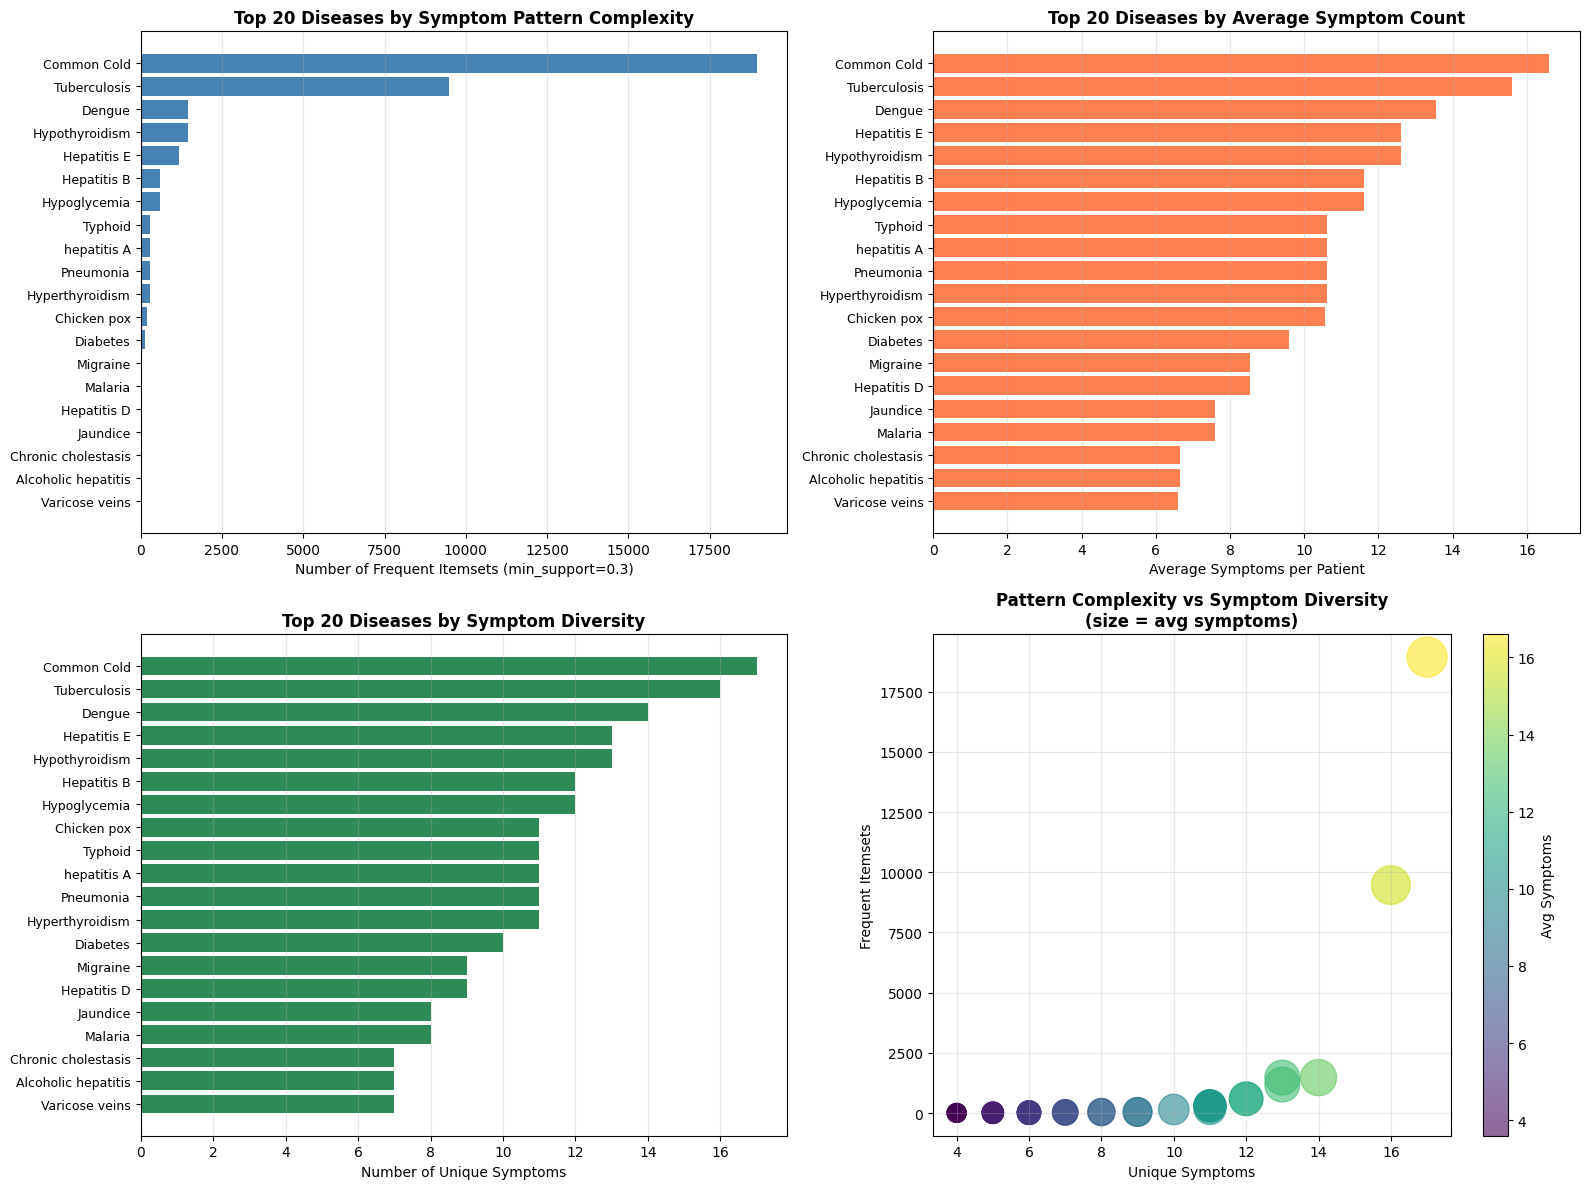

In [5]:
# Collect per-disease statistics
disease_stats = []

for disease in df_processed["Disease"].unique():
    disease_df = df_processed[df_processed["Disease"] == disease]
    disease_transactions = convert_to_transactions(disease_df)
    
    if len(disease_transactions) < 3:
        continue
    
    miner_disease = AprioriMiner(min_support=0.9)
    print(f"Fitting to disease - {disease}")
    miner_disease.fit(disease_transactions)
    
    # Calculate average symptoms per transaction
    avg_symptoms = np.mean([len(t) for t in disease_transactions])
    
    disease_stats.append({
        "disease": disease,
        "instances": len(disease_transactions),
        "frequent_itemsets": len(miner_disease.all_frequent_itemsets),
        "avg_symptoms": avg_symptoms,
        "unique_symptoms": len(set().union(*disease_transactions))
    })

stats_df = pd.DataFrame(disease_stats)

# Plot
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Frequent itemsets per disease
top_20 = stats_df.nlargest(20, "frequent_itemsets")
axes[0, 0].barh(range(len(top_20)), top_20["frequent_itemsets"], color="steelblue")
axes[0, 0].set_yticks(range(len(top_20)))
axes[0, 0].set_yticklabels(top_20["disease"], fontsize=9)
axes[0, 0].set_xlabel("Number of Frequent Itemsets (min_support=0.3)")
axes[0, 0].set_title("Top 20 Diseases by Symptom Pattern Complexity", 
                     fontweight="bold")
axes[0, 0].invert_yaxis()
axes[0, 0].grid(axis="x", alpha=0.3)

# 2. Average symptoms per disease
top_20_symptoms = stats_df.nlargest(20, "avg_symptoms")
axes[0, 1].barh(range(len(top_20_symptoms)), 
                top_20_symptoms["avg_symptoms"], color="coral")
axes[0, 1].set_yticks(range(len(top_20_symptoms)))
axes[0, 1].set_yticklabels(top_20_symptoms["disease"], fontsize=9)
axes[0, 1].set_xlabel("Average Symptoms per Patient")
axes[0, 1].set_title("Top 20 Diseases by Average Symptom Count", 
                     fontweight="bold")
axes[0, 1].invert_yaxis()
axes[0, 1].grid(axis="x", alpha=0.3)

# 3. Unique symptoms per disease
top_20_unique = stats_df.nlargest(20, "unique_symptoms")
axes[1, 0].barh(range(len(top_20_unique)), 
                top_20_unique["unique_symptoms"], color="seagreen")
axes[1, 0].set_yticks(range(len(top_20_unique)))
axes[1, 0].set_yticklabels(top_20_unique["disease"], fontsize=9)
axes[1, 0].set_xlabel("Number of Unique Symptoms")
axes[1, 0].set_title("Top 20 Diseases by Symptom Diversity", 
                     fontweight="bold")
axes[1, 0].invert_yaxis()
axes[1, 0].grid(axis="x", alpha=0.3)

# 4. Scatter: Complexity vs Diversity
axes[1, 1].scatter(stats_df["unique_symptoms"], 
                   stats_df["frequent_itemsets"],
                   s=stats_df["avg_symptoms"]*50, 
                   alpha=0.6, c=stats_df["avg_symptoms"],
                   cmap="viridis")
axes[1, 1].set_xlabel("Unique Symptoms")
axes[1, 1].set_ylabel("Frequent Itemsets")
axes[1, 1].set_title("Pattern Complexity vs Symptom Diversity\n"
                     "(size = avg symptoms)", fontweight="bold")
axes[1, 1].grid(alpha=0.3)

# Add colorbar
cbar = plt.colorbar(axes[1, 1].collections[0], ax=axes[1, 1])
cbar.set_label("Avg Symptoms")

plt.tight_layout()
plt.savefig("disease_complexity_analysis.png", dpi=300, bbox_inches="tight")
plt.show()

In [6]:
# Check for data uniformity across diseases
uniformity_scores = []

for disease in df_processed["Disease"].unique()[:10]:
    disease_df = df_processed[df_processed["Disease"] == disease]
    disease_transactions = convert_to_transactions(disease_df)
    
    if len(disease_transactions) < 10:
        continue
    
    # Check if all transactions are identical
    unique_trans = set(disease_transactions)
    uniformity = 1 - (len(unique_trans) / len(disease_transactions))
    
    uniformity_scores.append({
        "disease": disease,
        "total_transactions": len(disease_transactions),
        "unique_patterns": len(unique_trans),
        "uniformity": uniformity
    })

uniformity_df = pd.DataFrame(uniformity_scores)
print(uniformity_df.sort_values("uniformity", ascending=False))

               disease  total_transactions  unique_patterns  uniformity
0     Fungal infection                 120                5    0.958333
1              Allergy                 120                5    0.958333
6                 AIDS                 120                5    0.958333
8      Gastroenteritis                 120                5    0.958333
4        Drug Reaction                 120                6    0.950000
2                 GERD                 120                7    0.941667
5  Peptic ulcer diseae                 120                7    0.941667
9     Bronchial Asthma                 120                7    0.941667
3  Chronic cholestasis                 120                8    0.933333
7             Diabetes                 120                9    0.925000


Data is highly uniform. This means even at high minSup values, the number of frequent itemsets likely remains very high, especially for diseases with large number of symptoms, like common cold (no. of symptoms = 17).

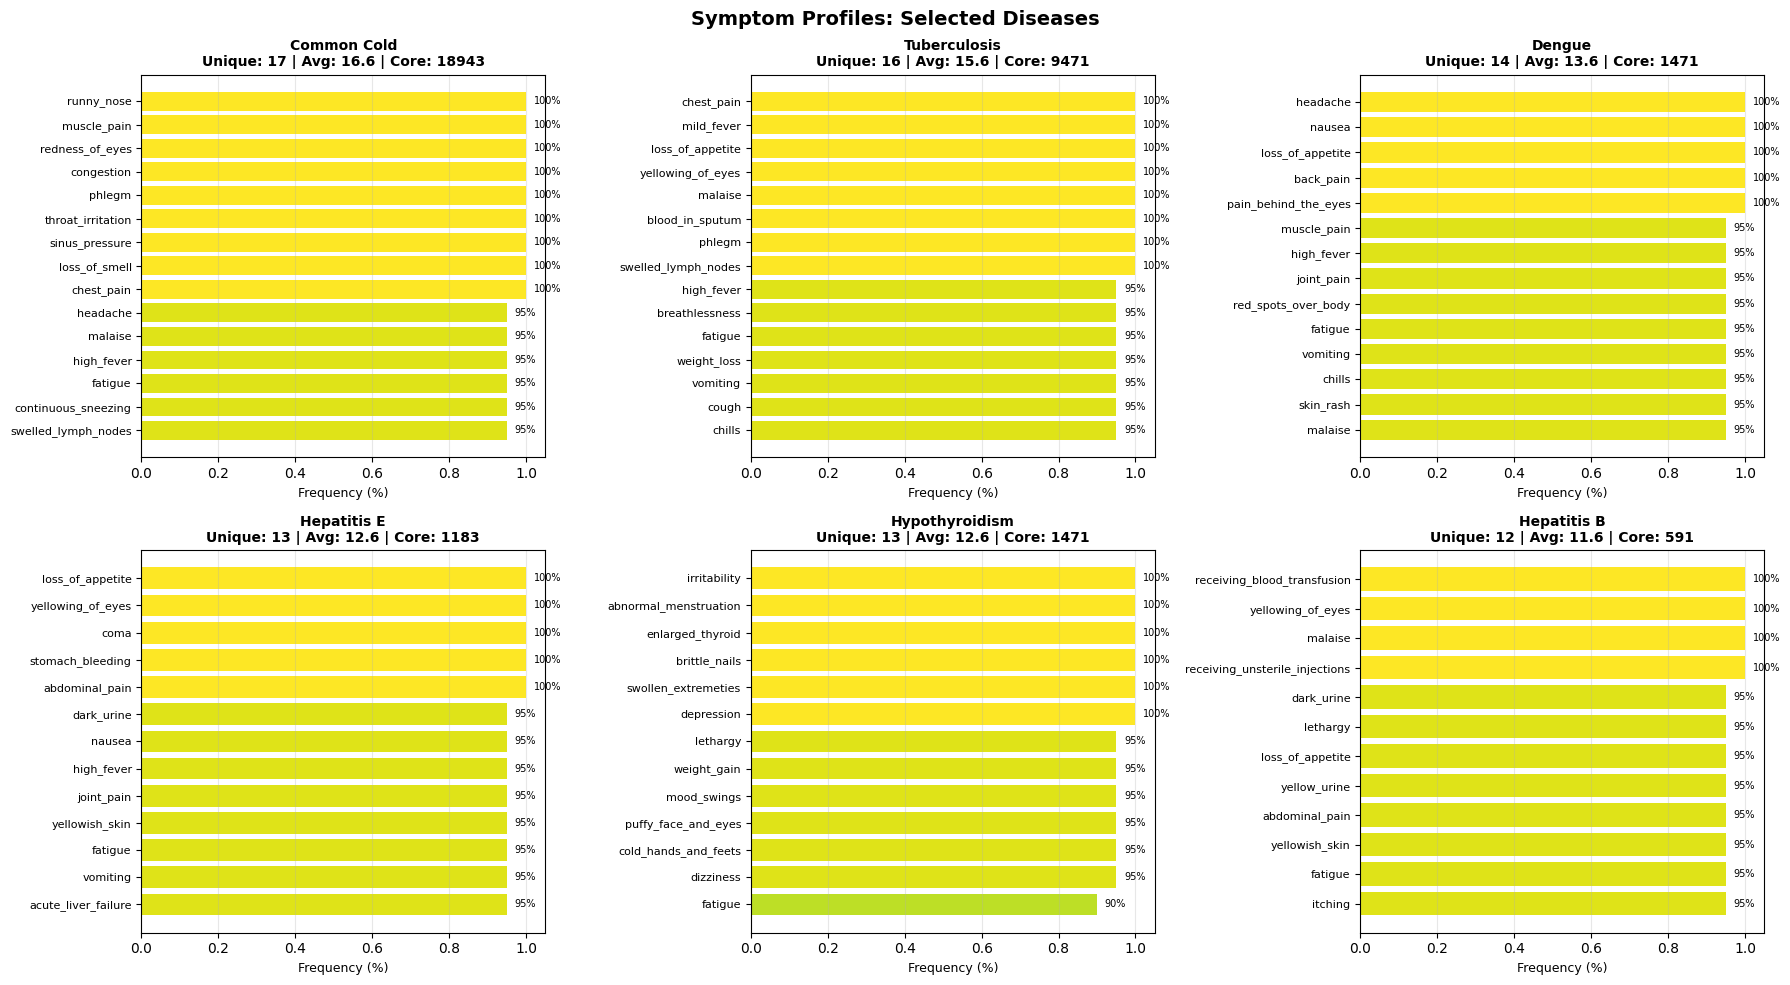

In [7]:
# Select top 6 most interesting diseases
from collections import Counter


# Get extremes for each metric while ensuring uniqueness
interesting_diseases = []
seen = set()

metrics = ["unique_symptoms", "avg_symptoms", "frequent_itemsets"]

for metric in metrics:
    # Get largest
    for _, row in stats_df.nlargest(10, metric).iterrows():
        disease = row["disease"]
        if disease not in seen:
            interesting_diseases.append(disease)
            seen.add(disease)
            if len(interesting_diseases) >= 6:
                break
    
    if len(interesting_diseases) >= 6:
        break
    
    # Get smallest
    for _, row in stats_df.nsmallest(10, metric).iterrows():
        disease = row["disease"]
        if disease not in seen:
            interesting_diseases.append(disease)
            seen.add(disease)
            if len(interesting_diseases) >= 6:
                break
    
    if len(interesting_diseases) >= 6:
        break

# Trim to 6
interesting_diseases = interesting_diseases[:6]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, disease in enumerate(interesting_diseases):
    disease_df = df_processed[df_processed["Disease"] == disease]
    disease_transactions = convert_to_transactions(disease_df)
    
    # Get symptom frequencies
    symptom_counts = Counter()
    for t in disease_transactions:
        symptom_counts.update(t)
    
    # Sort by frequency
    symptoms = [s for s, _ in symptom_counts.most_common(15)]
    frequencies = [symptom_counts[s]/len(disease_transactions) for s in symptoms]
    
    # Plot
    axes[idx].barh(range(len(symptoms)), frequencies, 
                   color=plt.cm.viridis(np.array(frequencies)))
    axes[idx].set_yticks(range(len(symptoms)))
    axes[idx].set_yticklabels(symptoms, fontsize=8)
    axes[idx].set_xlabel("Frequency (%)", fontsize=9)
    axes[idx].set_xlim(0, 1.05)
    
    # Add percentage labels
    for i, (symptom, freq) in enumerate(zip(symptoms, frequencies)):
        axes[idx].text(freq + 0.02, i, f"{freq*100:.0f}%", 
                      va="center", fontsize=7)
    
    # Title with stats
    disease_stat = stats_df[stats_df["disease"]==disease].iloc[0]
    axes[idx].set_title(
        f"{disease}\n"
        f"Unique: {disease_stat['unique_symptoms']:.0f} | "
        f"Avg: {disease_stat['avg_symptoms']:.1f} | "
        f"Core: {disease_stat['frequent_itemsets']:.0f}",
        fontweight="bold", fontsize=10
    )
    axes[idx].invert_yaxis()
    axes[idx].grid(axis="x", alpha=0.3)

plt.suptitle("Symptom Profiles: Selected Diseases", 
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("disease_symptom_profiles.png", dpi=300, bbox_inches="tight")
plt.show()

In [8]:
# Extract rules for 6 interesting diseases
interesting_rules_collection = {}

print("\n" + "="*80)
print("RULES FOR INTERESTING DISEASES")
print("="*80)

for disease in interesting_diseases:
    disease_df = df_processed[df_processed["Disease"] == disease]
    disease_transactions = convert_to_transactions(disease_df)
    
    # Run Apriori
    miner = AprioriMiner(min_support=0.9)
    miner.fit(disease_transactions)
    rules = miner.generate_rules(min_confidence=0.5, min_lift=1.0)
    
    rules_df = miner.get_rules_df()
    rules_df["disease"] = disease
    
    interesting_rules_collection[disease] = rules_df
    
    print(f"\n{disease}:")
    print(f"  Rules: {len(rules_df)}")
    if len(rules_df) > 0:
        print(f"  Top rule: {rules_df.iloc[0]['rule_str']}")
        print(f"    Confidence: {rules_df.iloc[0]['confidence']:.2%}")
        print(f"    Lift: {rules_df.iloc[0]['lift']:.2f}")

# Combine all
interesting_rules_df = pd.concat(
    interesting_rules_collection.values(), 
    ignore_index=True
)

print(f"\n\nTotal rules for interesting diseases: {len(interesting_rules_df)}")
# interesting_rules_df.to_csv("interesting_disease_rules.csv", index=False)


RULES FOR INTERESTING DISEASES
Fitting Apriori with min_support=0.9 (count=108)
Total transactions: 120
Generating 1-itemsets...
  Found 17 frequent 1-itemsets
Generating 2-itemsets...
  Found 136 frequent 2-itemsets
Generating 3-itemsets...
  Found 624 frequent 3-itemsets
Generating 4-itemsets...
  Found 1806 frequent 4-itemsets
Generating 5-itemsets...
  Found 3486 frequent 5-itemsets
Generating 6-itemsets...
  Found 4620 frequent 6-itemsets
Generating 7-itemsets...
  Found 4236 frequent 7-itemsets
Generating 8-itemsets...
  Found 2649 frequent 8-itemsets
Generating 9-itemsets...
  Found 1081 frequent 9-itemsets
Generating 10-itemsets...
  Found 260 frequent 10-itemsets
Generating 11-itemsets...
  Found 28 frequent 11-itemsets
Generating 12-itemsets...
Total frequent itemsets: 18943

Generated 1398972 association rules
  Min confidence: 0.5
  Min lift: 1.0

Common Cold:
  Rules: 1398972
  Top rule: chest_pain → muscle_pain
    Confidence: 100.00%
    Lift: 1.00
Fitting Apriori with 

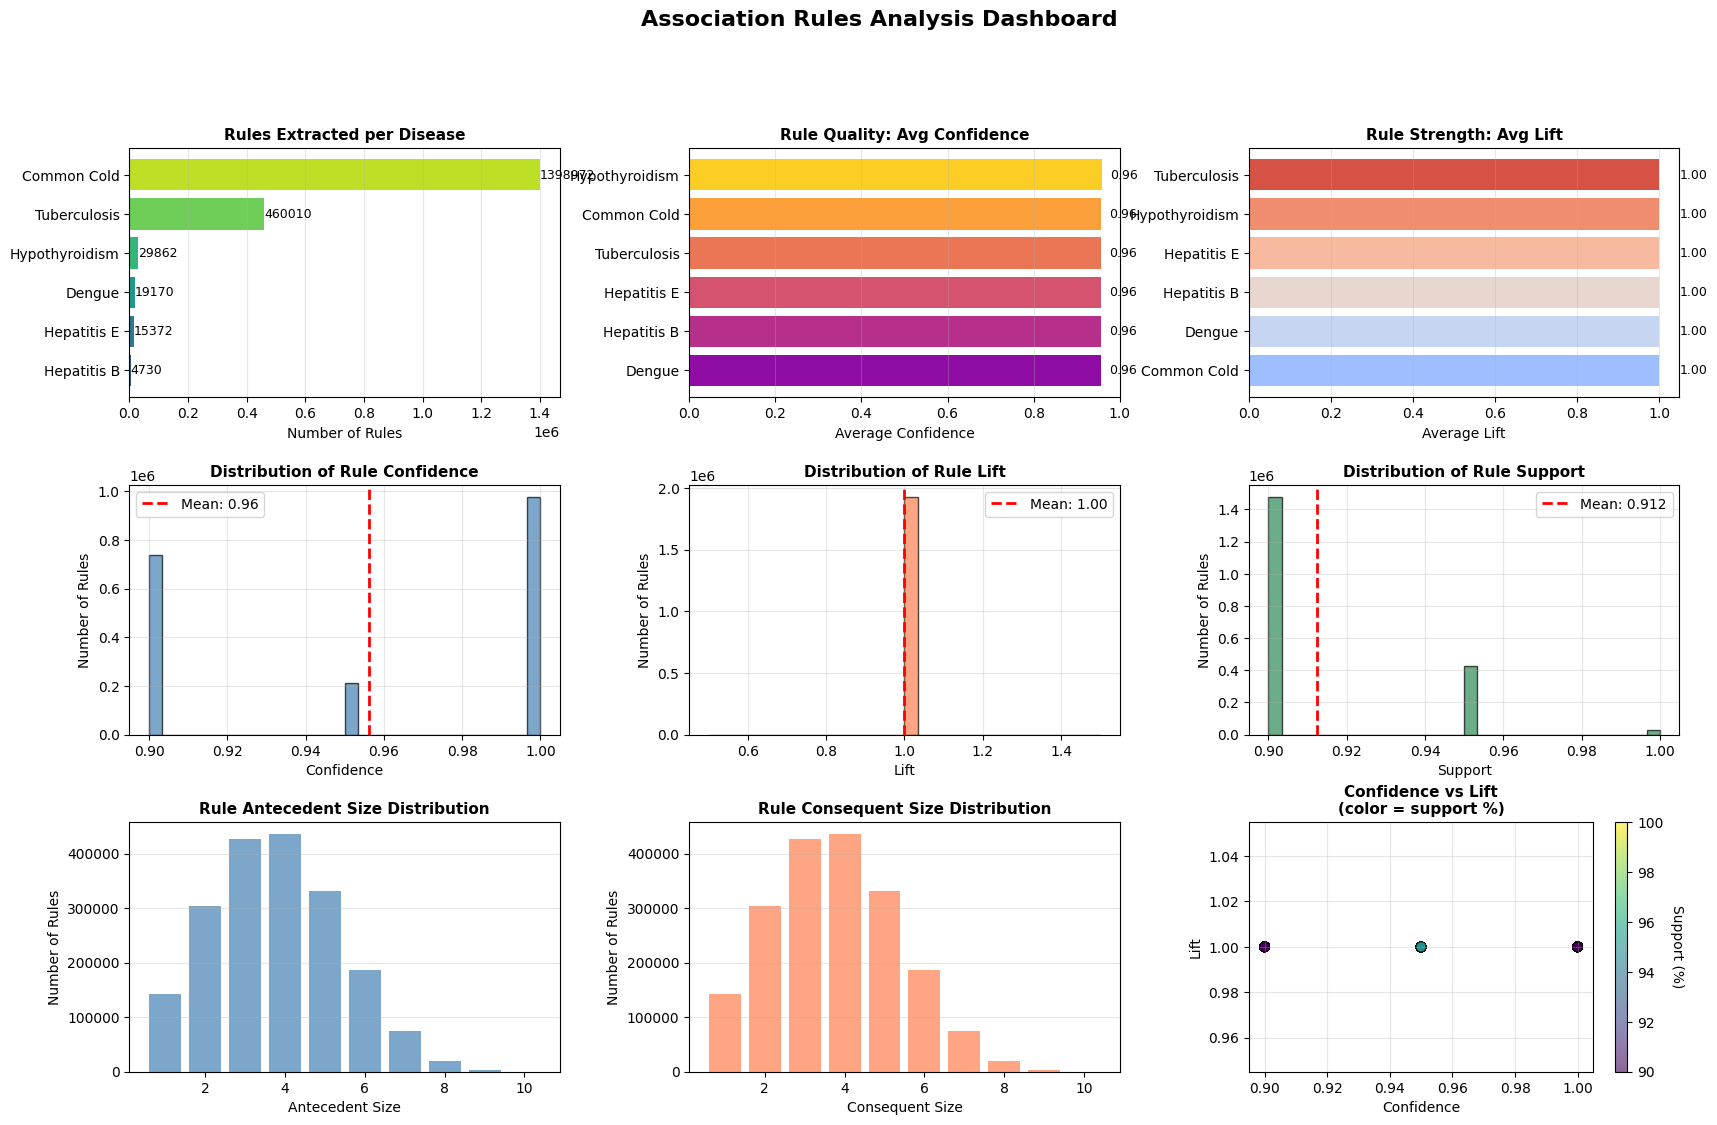

In [9]:
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)

# 1. Rules per disease
ax1 = fig.add_subplot(gs[0, 0])
rules_per_disease = interesting_rules_df.groupby("disease").size().sort_values()
bars1 = ax1.barh(range(len(rules_per_disease)), rules_per_disease.values,
                  color=plt.cm.viridis(np.linspace(0.3, 0.9, len(rules_per_disease))))
ax1.set_yticks(range(len(rules_per_disease)))
ax1.set_yticklabels(rules_per_disease.index, fontsize=10)
ax1.set_xlabel("Number of Rules")
ax1.set_title("Rules Extracted per Disease", fontweight="bold", fontsize=11)
ax1.grid(axis="x", alpha=0.3)
for i, v in enumerate(rules_per_disease.values):
    ax1.text(v + 0.5, i, str(v), va="center", fontsize=9)

# 2. Average confidence by disease
ax2 = fig.add_subplot(gs[0, 1])
avg_conf = interesting_rules_df.groupby("disease")["confidence"].mean().sort_values()
bars2 = ax2.barh(range(len(avg_conf)), avg_conf.values,
                  color=plt.cm.plasma(np.linspace(0.3, 0.9, len(avg_conf))))
ax2.set_yticks(range(len(avg_conf)))
ax2.set_yticklabels(avg_conf.index, fontsize=10)
ax2.set_xlabel("Average Confidence")
ax2.set_xlim(0, 1)
ax2.set_title("Rule Quality: Avg Confidence", fontweight="bold", fontsize=11)
ax2.grid(axis="x", alpha=0.3)
for i, v in enumerate(avg_conf.values):
    ax2.text(v + 0.02, i, f"{v:.2f}", va="center", fontsize=9)

# 3. Average lift by disease
ax3 = fig.add_subplot(gs[0, 2])
avg_lift = interesting_rules_df.groupby("disease")["lift"].mean().sort_values()
bars3 = ax3.barh(range(len(avg_lift)), avg_lift.values,
                  color=plt.cm.coolwarm(np.linspace(0.3, 0.9, len(avg_lift))))
ax3.set_yticks(range(len(avg_lift)))
ax3.set_yticklabels(avg_lift.index, fontsize=10)
ax3.set_xlabel("Average Lift")
ax3.set_title("Rule Strength: Avg Lift", fontweight="bold", fontsize=11)
ax3.grid(axis="x", alpha=0.3)
for i, v in enumerate(avg_lift.values):
    ax3.text(v + 0.05, i, f"{v:.2f}", va="center", fontsize=9)

# 4. Distribution: Confidence
ax4 = fig.add_subplot(gs[1, 0])
ax4.hist(interesting_rules_df["confidence"], bins=30, color="steelblue", 
         alpha=0.7, edgecolor="black")
ax4.axvline(interesting_rules_df["confidence"].mean(), color="red", 
            linestyle="--", linewidth=2, label=f'Mean: {interesting_rules_df["confidence"].mean():.2f}')
ax4.set_xlabel("Confidence")
ax4.set_ylabel("Number of Rules")
ax4.set_title("Distribution of Rule Confidence", fontweight="bold", fontsize=11)
ax4.legend()
ax4.grid(alpha=0.3)

# 5. Distribution: Lift
ax5 = fig.add_subplot(gs[1, 1])
ax5.hist(interesting_rules_df["lift"], bins=30, color="coral", 
         alpha=0.7, edgecolor="black")
ax5.axvline(interesting_rules_df["lift"].mean(), color="red", 
            linestyle="--", linewidth=2, label=f'Mean: {interesting_rules_df["lift"].mean():.2f}')
ax5.set_xlabel("Lift")
ax5.set_ylabel("Number of Rules")
ax5.set_title("Distribution of Rule Lift", fontweight="bold", fontsize=11)
ax5.legend()
ax5.grid(alpha=0.3)

# 6. Distribution: Support
ax6 = fig.add_subplot(gs[1, 2])
ax6.hist(interesting_rules_df["support"], bins=30, color="seagreen", 
         alpha=0.7, edgecolor="black")
ax6.axvline(interesting_rules_df["support"].mean(), color="red", 
            linestyle="--", linewidth=2, label=f'Mean: {interesting_rules_df["support"].mean():.3f}')
ax6.set_xlabel("Support")
ax6.set_ylabel("Number of Rules")
ax6.set_title("Distribution of Rule Support", fontweight="bold", fontsize=11)
ax6.legend()
ax6.grid(alpha=0.3)

# 7. Antecedent size distribution
ax7 = fig.add_subplot(gs[2, 0])
interesting_rules_df["antecedent_size"] = interesting_rules_df["antecedent"].apply(len)
ant_size_dist = interesting_rules_df["antecedent_size"].value_counts().sort_index()
ax7.bar(ant_size_dist.index, ant_size_dist.values, color="steelblue", alpha=0.7)
ax7.set_xlabel("Antecedent Size")
ax7.set_ylabel("Number of Rules")
ax7.set_title("Rule Antecedent Size Distribution", fontweight="bold", fontsize=11)
ax7.grid(axis="y", alpha=0.3)

# 8. Consequent size distribution
ax8 = fig.add_subplot(gs[2, 1])
interesting_rules_df["consequent_size"] = interesting_rules_df["consequent"].apply(len)
cons_size_dist = interesting_rules_df["consequent_size"].value_counts().sort_index()
ax8.bar(cons_size_dist.index, cons_size_dist.values, color="coral", alpha=0.7)
ax8.set_xlabel("Consequent Size")
ax8.set_ylabel("Number of Rules")
ax8.set_title("Rule Consequent Size Distribution", fontweight="bold", fontsize=11)
ax8.grid(axis="y", alpha=0.3)

# 9. Confidence vs Lift scatter
ax9 = fig.add_subplot(gs[2, 2])
scatter = ax9.scatter(interesting_rules_df["confidence"], 
                     interesting_rules_df["lift"],
                     c=interesting_rules_df["support"]*100,
                     s=50, alpha=0.6, cmap="viridis", edgecolors="black", linewidth=0.5)
ax9.set_xlabel("Confidence")
ax9.set_ylabel("Lift")
ax9.set_title("Confidence vs Lift\n(color = support %)", fontweight="bold", fontsize=11)
ax9.grid(alpha=0.3)
cbar = plt.colorbar(scatter, ax=ax9)
cbar.set_label("Support (%)", rotation=270, labelpad=15)

plt.suptitle("Association Rules Analysis Dashboard", 
             fontsize=16, fontweight="bold", y=0.995)
# plt.savefig("rules_analysis_dashboard.png", dpi=300, bbox_inches="tight")
plt.show()

## Top Rules for Interesting Diseases

This section extracts and displays the top association rules for each interesting disease, sorted by confidence and lift. We show the top 5 rules per disease (or all if fewer), along with key metrics.

In [ ]:
# Extract and display top rules for each interesting disease
for disease in interesting_diseases:
    rules_df = interesting_rules_collection.get(disease)
    if rules_df is None or rules_df.empty:
        print(f"\n{disease}: No rules generated.")
        continue
    
    # Filter for high-quality rules
    filtered_rules = rules_df[(rules_df['confidence'] > 0.7) & (rules_df['lift'] > 1.2)]
    if filtered_rules.empty:
        print(f"\n{disease}: No high-quality rules (confidence > 70%, lift > 1.2).")
        continue
    
    # Sort by confidence, then lift
    top_rules = filtered_rules.sort_values(['confidence', 'lift'], ascending=[False, False]).head(5)
    
    print(f"\n{disease} - Top {len(top_rules)} Rules:")
    for idx, row in top_rules.iterrows():
        print(f"  Rule: {row['rule_str']}")
        print(f"    Support: {row['support']*100:.1f}%, Confidence: {row['confidence']*100:.1f}%, Lift: {row['lift']:.2f}")
        print()

In [ ]:
# Visualizations for top rules
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for all diseases
all_top_rules = []
for disease in interesting_diseases:
    rules_df = interesting_rules_collection.get(disease)
    if rules_df is not None and not rules_df.empty:
        filtered = rules_df[(rules_df['confidence'] > 0.7) & (rules_df['lift'] > 1.2)]
        top = filtered.sort_values(['confidence', 'lift'], ascending=[False, False]).head(5)
        top = top.copy()
        top['disease'] = disease
        all_top_rules.append(top)

if all_top_rules:
    combined_df = pd.concat(all_top_rules, ignore_index=True)
    
    if combined_df.empty:
        print("No high-quality rules to visualize after filtering.")
    else:
        # Overall scatter plot: Confidence vs Lift
        fig, ax = plt.subplots(figsize=(10, 6))
        scatter = ax.scatter(combined_df['confidence'], combined_df['lift'], 
                             c=combined_df['disease'].astype('category').cat.codes, 
                             s=combined_df['support']*1000, alpha=0.7, cmap='tab10')
        ax.set_xlabel('Confidence')
        ax.set_ylabel('Lift')
        ax.set_title('Top Rules: Confidence vs Lift (Size = Support)')
        ax.grid(alpha=0.3)
        
        # Legend
        handles, labels = scatter.legend_elements(prop="colors")
        disease_labels = combined_df['disease'].unique()
        ax.legend(handles, disease_labels, title="Disease")
        
        # plt.savefig('top_rules_scatter.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        # Per-disease bar charts for top rules
        diseases_with_rules = combined_df['disease'].unique()
        n_diseases = len(diseases_with_rules)
        fig, axes = plt.subplots(n_diseases, 2, figsize=(14, 4*n_diseases), squeeze=False)
        
        for i, disease in enumerate(diseases_with_rules):
            disease_rules = combined_df[combined_df['disease'] == disease]
            
            # Confidence bar
            axes[i, 0].barh(range(len(disease_rules)), disease_rules['confidence'], 
                            color=plt.cm.viridis(disease_rules['lift'] / disease_rules['lift'].max()))
            axes[i, 0].set_yticks(range(len(disease_rules)))
            axes[i, 0].set_yticklabels(disease_rules['rule_str'], fontsize=8)
            axes[i, 0].set_xlabel('Confidence')
            axes[i, 0].set_title(f'{disease} - Confidence')
            axes[i, 0].grid(axis='x', alpha=0.3)
            
            # Lift bar
            axes[i, 1].barh(range(len(disease_rules)), disease_rules['lift'], 
                            color=plt.cm.plasma(disease_rules['confidence']))
            axes[i, 1].set_yticks(range(len(disease_rules)))
            axes[i, 1].set_yticklabels(disease_rules['rule_str'], fontsize=8)
            axes[i, 1].set_xlabel('Lift')
            axes[i, 1].set_title(f'{disease} - Lift')
            axes[i, 1].grid(axis='x', alpha=0.3)
        
        plt.tight_layout()
        # plt.savefig('top_rules_bars.png', dpi=300, bbox_inches='tight')
        plt.show()
else:
    print("No high-quality rules to visualize.")